In [9]:
import matplotlib.pyplot as plt

from orbitalsim.universal_constants import UniversalConstants
from orbitalsim.celestial_body import CelestialBody
from orbitalsim.planets import Planets
from orbitalsim.diagnostic_calculators import *
from orbitalsim.simulation import NBodySimulation

from orbitalsim.integrators.symplectic_euler import SymplecticEulerIntegrator

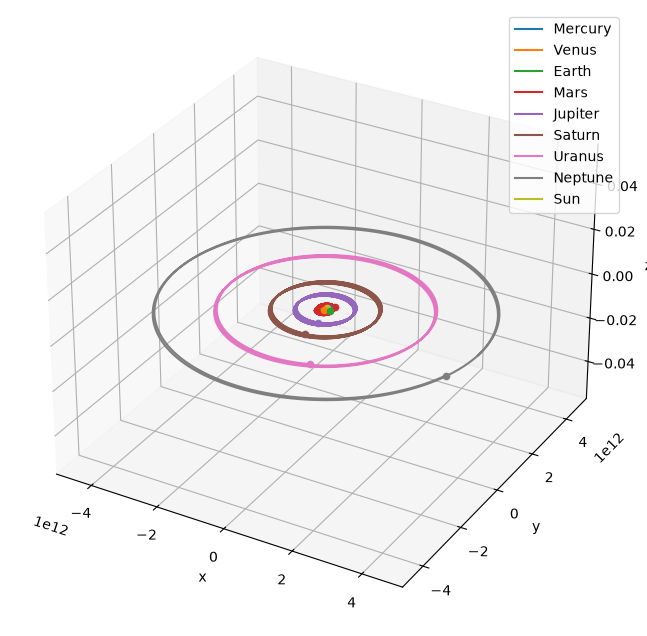

In [7]:
class SimulationRunner:

    integrator = SymplecticEulerIntegrator()

    sun = CelestialBody(1.989e30, np.array([0.0, 0.0, 0.0]), np.array([0.0, 0.0, 0.0]), name="Sun")

    all_bodies = Planets().allPlanets.copy()
    all_bodies.append(sun)

    simulation = NBodySimulation(integrator, bodies=all_bodies)

    traj, _, _, _, _, _, _ = simulation.Simulator(1000000)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    for i, body in enumerate(simulation.bodies):
        ax.plot(
            traj[:, i, 0],
            traj[:, i, 1],
            traj[:, i, 2],
            label = body.name
        )

        # final pos
        ax.scatter(
            traj[-1, i, 0],
            traj[-1, i, 1],
            traj[-1, i, 2],
        )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend()

    plt.show()

With the current symplectic Euler integrator, energy stays bounded. For 1000000 steps of time step of 10000, total mechanical energy remains between
-1.9811296387379416e+35 and -1.9811315895130897e+35, with an execution time of 13 minutes